# TsUtils — 时间序列预处理与识别诊断

## Goal

本 demo 按可复现顺序演示 `TsUtils` 的五项公共能力：差分、缺失值插值、统计摘要与相关图、EACF 阶数识别和 STL 分解。所有数据均在本地确定性生成，不依赖外部文件。

## Setup

导入公共接口并生成一条带趋势和月度季节性的完整序列。

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import sys
from pathlib import Path

# 支持从仓库内的 TsUtils 目录直接执行本 Notebook。
working_directory = Path.cwd().resolve()
package_directory = next(
    (
        candidate
        for candidate in (working_directory, *working_directory.parents)
        if candidate.name == "Ts" and (candidate / "TsUtils").is_dir()
    ),
    None,
)
if package_directory is not None:
    sys.path.insert(0, str(package_directory.parent))

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
plot_font = next(
    (name for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC") if name in available_fonts),
    "DejaVu Sans",
)
plt.rcParams["font.sans-serif"] = [plot_font]
plt.rcParams["axes.unicode_minus"] = False

from Ts.TsUtils import (
    STL,
    TimeSeriesSummary,
    difference,
    eacf,
    interpolate_missing,
)

rng = np.random.default_rng(20260730)
index = pd.date_range("2015-01-01", periods=120, freq="MS")
time = np.arange(len(index))
complete_series = pd.Series(
    100 + 0.25 * time + 8 * np.sin(2 * np.pi * time / 12) + rng.normal(scale=1.2, size=len(index)),
    index=index,
    name="sales",
)
complete_series.head()

2015-01-01    101.621893
2015-02-01    105.289677
2015-03-01    108.357404
2015-04-01    107.971891
2015-05-01    109.415334
Freq: MS, Name: sales, dtype: float64

## Steps

### 1. 普通差分与同比对数差分

`difference()` 保留原索引和序列长度；差分产生的前置缺失值不会被静默删除。

In [2]:
first_difference = difference(complete_series)
yoy_log_difference = difference(complete_series, log=True, lag=12)

pd.DataFrame(
    {
        "level": complete_series,
        "first_difference": first_difference,
        "yoy_log_difference": yoy_log_difference,
    }
).tail(15)

,level,first_difference,yoy_log_difference
2023-10-01,119.046088,-1.269033,0.012368
2023-11-01,119.016658,-0.029429,0.017935
2023-12-01,122.871987,3.855329,0.026375
2024-01-01,126.523159,3.651172,0.024944
2024-02-01,133.386944,6.863785,0.030286
2024-03-01,131.941043,-1.445902,-0.002284
2024-04-01,136.310670,4.369628,0.023345
2024-05-01,136.070880,-0.239790,0.035307
2024-06-01,131.234504,-4.836376,0.033925
2024-07-01,128.680855,-2.553649,0.021349


### 2. 缺失值插值及审计信息

这里人为制造一个两期内部缺口。`max_gap=2` 允许填补该缺口，`edge="keep"` 不外推序列边界。

In [3]:
series_with_gap = complete_series.copy()
series_with_gap.iloc[24:26] = np.nan

interpolation = interpolate_missing(
    series_with_gap,
    method="linear",
    max_gap=2,
    edge="keep",
)
print(interpolation.summary())

pd.DataFrame(
    {
        "original": series_with_gap,
        "interpolated": interpolation.data,
        "filled": interpolation.filled_mask,
    }
).iloc[21:29]

Interpolation Result
Method          : linear
Maximum gap     : 2
Edge policy     : keep
Missing values  : 2
Filled values   : 2
Remaining       : 0
Complete        : True


,original,interpolated,filled
2016-10-01,96.818722,96.818722,False
2016-11-01,98.974098,98.974098,False
2016-12-01,102.284516,102.284516,False
2017-01-01,NaN,105.975189,True
2017-02-01,NaN,109.665863,True
2017-03-01,113.356537,113.356537,False
2017-04-01,115.621117,115.621117,False
2017-05-01,115.225811,115.225811,False


### 3. 统计摘要与 ACF/PACF 诊断

摘要和相关图使用完整序列。若输入含缺失值，诊断不会自动删行或插值。

In [4]:
summary = TimeSeriesSummary(complete_series, nlags=18)
print(summary.summary(plot=False))

Time Series Summary
Name               : sales
Observations       : 120
Valid observations : 120
Frequency          : MS
Start              : 2015-01-01T00:00:00
End                : 2024-12-01T00:00:00
Missing values     : 0
Missing ratio      : 0.00%
Missing timestamps : None
--------------------------------------------------
Mean               : 114.888
Standard deviation : 10.1118
Minimum            : 92.6547
First quartile     : 107.91
Median             : 114.945
Third quartile     : 122.824
Maximum            : 136.311


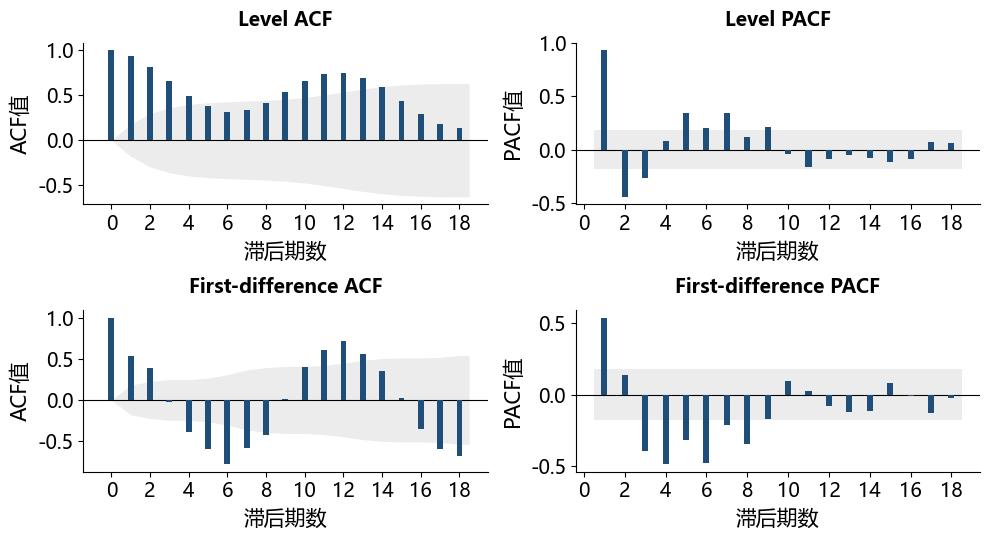

In [5]:
figure, axes = summary.plot()
plt.show()

### 4. EACF：非季节 ARMA 阶数识别

构造一条 AR(2) 序列并生成 EACF 表。行是 AR 阶数 `p`，列是 MA 阶数 `q`；`o` 三角形只用于提出候选阶数，不自动决定模型。

In [6]:
innovations = rng.normal(size=500)
ar2_values = np.zeros(500)
for position in range(2, len(ar2_values)):
    ar2_values[position] = (
        0.65 * ar2_values[position - 1]
        - 0.25 * ar2_values[position - 2]
        + innovations[position]
    )

ar2_series = pd.Series(ar2_values[100:], name="ar2")
eacf_result = eacf(ar2_series, ar_max=5, ma_max=5)
print(eacf_result.summary())

Extended Autocorrelation Function
Observations: 400
AR\MA    0    1    2    3    4    5
    0    x    x    o    x    o    o
    1    x    x    x    x    o    o
    2    x    o    o    x    o    o
    3    o    o    o    o    x    o
    4    o    x    o    o    o    o
    5    x    x    o    o    o    o
x = significant
o = not significant


### 5. STL 分解

月度数据显式设置 `period=12`。结果提供趋势、季节项、残差、权重和拟合值。

STL Decomposition Result
Observations       : 120
Period             : 12
Robust             : True
Seasonal smoother  : 7
Trend smoother     : 23
Low-pass smoother  : 13
Residual std. dev. : 1.008141


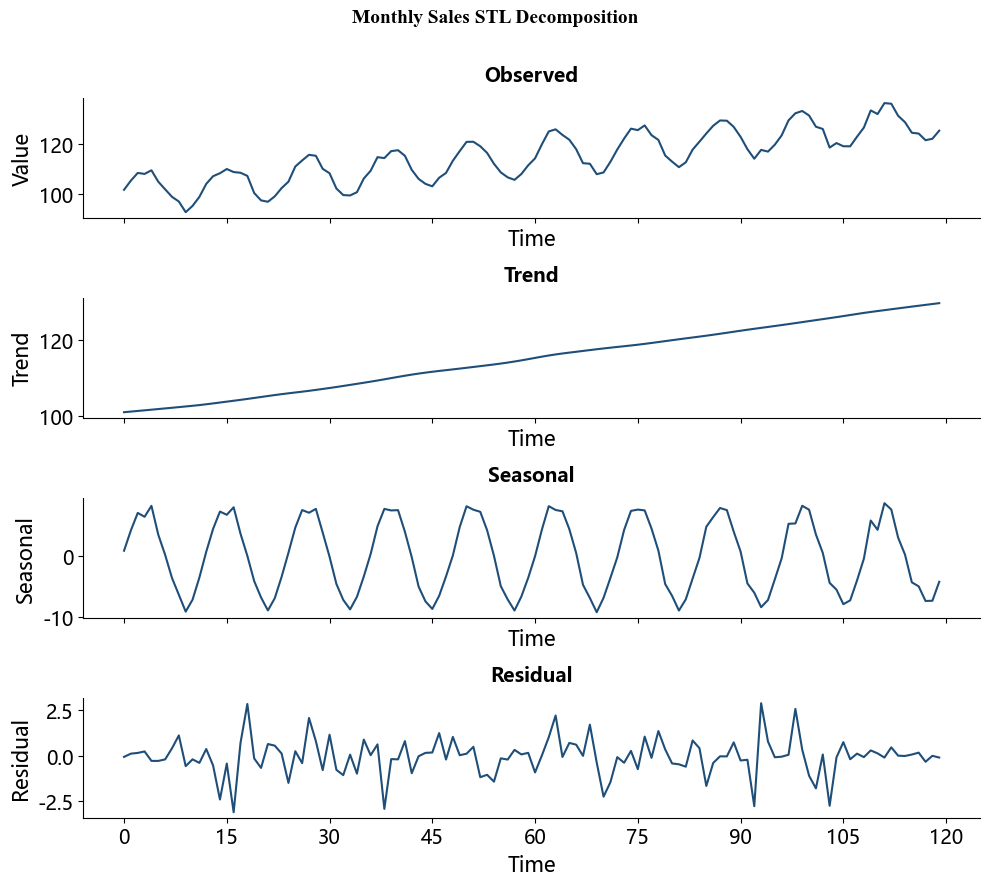

In [7]:
stl_result = STL(complete_series, period=12, robust=True).fit()
print(stl_result.summary())
stl_result.plot(title="Monthly Sales STL Decomposition")
plt.show()

## Checks

以下断言检查容器、缺失值审计、EACF 维度和 STL 分解恒等式。

In [8]:
assert first_difference.index.equals(complete_series.index)
assert first_difference.iloc[0:].isna().sum() == 1
assert interpolation.n_missing == 2
assert interpolation.n_filled == 2
assert interpolation.complete
assert eacf_result.values.shape == (6, 6)
assert eacf_result.symbols.shape == (6, 6)
np.testing.assert_allclose(
    np.asarray(stl_result.observed),
    np.asarray(stl_result.trend + stl_result.seasonal + stl_result.residuals),
    rtol=1e-10,
    atol=1e-10,
)
print("All TsUtils demo checks passed.")

All TsUtils demo checks passed.


## Next Steps

- 对真实数据先检查频率、缺失机制和结构突变，再选择差分、插值或分解。
- EACF 只识别非季节 ARMA 候选；最终阶数需结合参数估计、残差诊断和样本外表现。
- STL 的周期必须由数据频率和业务含义明确给出，不应仅凭列名猜测。